In [9]:
from src import *
from glob import glob

In [2]:
for f in ['__estimates__/noisy/di_5px/*',
          '__estimates__/noisy/spade_5px/*']:
    
    for ff in glob(f):
        c = LoadEstimates(ff)
        c.cropped_data = c.croppend_data[:200]
        c_ = Estimation.FromEstimates(c)
        c_.savez('4_pi-1')

In [ ]:
# STOP HERE
raise

In [52]:
from myutils import cache, clean_all_cache

from src import *
from glob import glob

from src.fisherinfo import FisherInformation, ApproxFisherInformation, FrequencyCFI

from matplotlib.ticker import AutoMinorLocator, ScalarFormatter


c1 = '#1f77b4'
c2 = '#2ca02c'

red = '#d62728'

width = 8.5 / 2.54 #inches

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

In [56]:
c_spade = LoadEstimates(rf'__estimates__/noisy/spade_5px/spade_5px_f0.2_d{0}.npz')
c_di = LoadEstimates(rf'__estimates__/noisy/di_5px/di_5px_f0.2_d{0}.npz')

spade_pn = c_spade.photons.mean() - qCMOS.convert2photons(c_spade.background, 0).mean()
di_pn = c_di.photons.mean() - qCMOS.convert2photons(c_di.background, 0).mean()

def read_noisy_est():
    spade_est, di_est = [], []
    spade_b, di_b = [], []
    for d in np.arange(0, 101, 2):
        spade_c = LoadEstimates(rf'__estimates__/noisy/spade_5px/spade_5px_f0.2_d{d}.npz')
        di_c = LoadEstimates(rf'__estimates__/noisy/di_5px/di_5px_f0.2_d{d}.npz')

        spade_est.append(spade_c.estimates_a)
        di_est.append(di_c.estimates_a)

        spade_b.append(spade_c.background.mean())
        di_b.append(di_c.background.mean())

    return np.array(spade_est).mean(-1), \
           np.array(di_est).mean(-1), \
           np.array(spade_est).var(-1, ddof=1) * spade_pn, \
           np.array(di_est).var(-1, ddof=1) * di_pn, \
           qCMOS.convert2photons(np.array(spade_b)) / spade_pn, \
           qCMOS.convert2photons(np.array(di_b)) / di_pn


spade_means, di_means, spade_vars1, di_vars1, spade_b, di_b = read_noisy_est()

dicfi =  lambda b: FrequencyCFI(DI).cal(0.2, 5*DMD.PIXEL_SIZE/2, [b, 4.6])
spadecfi =  lambda b: FrequencyCFI(BiSPADE).cal(0.2, 5*DMD.PIXEL_SIZE/2, [b])

b = np.linspace(1e-10, 0.1, 300)
ratio = np.array([dicfi(_b) / spadecfi(_b) for _b in b])

di_crb, spade_crb = 1/np.array([dicfi(_b) for _b in di_b]), 1/np.array([spadecfi(_b) for _b in spade_b])

In [57]:
c_spade = LoadEstimates(rf'4_pi-1/spade_5px_f0.2_d{0}.npz')
c_di = LoadEstimates(rf'4_pi-1/di_5px_f0.2_d{0}.npz')

spade_pn = c_spade.photons.mean() - qCMOS.convert2photons(c_spade.background, 0).mean()
di_pn = c_di.photons.mean() - qCMOS.convert2photons(c_di.background, 0).mean()

def read_noisy_est():
    spade_est, di_est = [], []
    spade_b, di_b = [], []
    for d in np.arange(0, 101, 2):
        spade_c = LoadEstimates(rf'4_pi-1/spade_5px_f0.2_d{d}.npz')
        di_c = LoadEstimates(rf'4_pi-1/di_5px_f0.2_d{d}.npz')

        spade_est.append(spade_c.estimates_a)
        di_est.append(di_c.estimates_a)

        spade_b.append(spade_c.background.mean())
        di_b.append(di_c.background.mean())

    return np.array(spade_est).mean(-1), \
           np.array(di_est).mean(-1), \
           np.array(spade_est).var(-1, ddof=1) * spade_pn, \
           np.array(di_est).var(-1, ddof=1) * di_pn, \
           qCMOS.convert2photons(np.array(spade_b)) / spade_pn, \
           qCMOS.convert2photons(np.array(di_b)) / di_pn


spade_means, di_means, spade_vars2, di_vars2, spade_b, di_b = read_noisy_est()

dicfi =  lambda b: FrequencyCFI(DI).cal(0.2, 5*DMD.PIXEL_SIZE/2, [b, 4.6])
spadecfi =  lambda b: FrequencyCFI(BiSPADE).cal(0.2, 5*DMD.PIXEL_SIZE/2, [b])

b = np.linspace(1e-10, 0.1, 300)
ratio = np.array([dicfi(_b) / spadecfi(_b) for _b in b])

di_crb, spade_crb = 1/np.array([dicfi(_b) for _b in di_b]), 1/np.array([spadecfi(_b) for _b in spade_b])

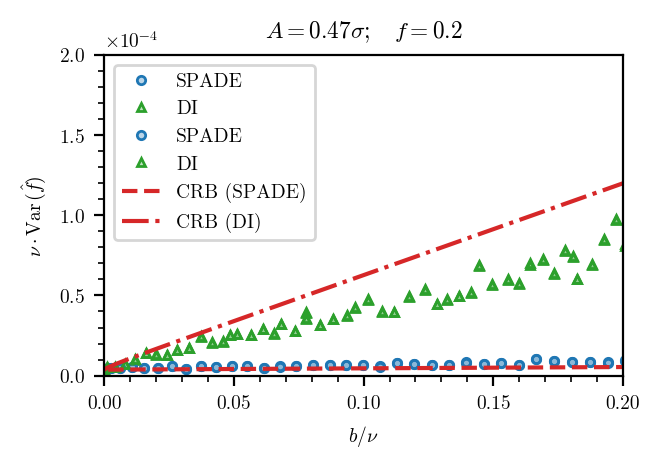

In [60]:
plt.figure(figsize=(width, width))


plt.plot(spade_b, spade_vars1, color='#1f77b4', marker='o', 
         linestyle='', markersize=3, 
         markeredgecolor='#1f77b4', markerfacecolor=('#1f77b4', 0.3),
         label='SPADE')

plt.plot(di_b, di_vars1, color='#2ca02c', marker='^', 
         linestyle='', markersize=3, 
         markeredgecolor='#2ca02c', markerfacecolor=('#2ca02c', 0.3),
         label='DI')

plt.plot(spade_b, spade_vars2, color='#1f77b4', marker='o', 
         linestyle='', markersize=3, 
         markeredgecolor='#1f77b4', markerfacecolor=('#1f77b4', 0.3),
         label='SPADE')

plt.plot(di_b, di_vars2, color='#2ca02c', marker='^', 
         linestyle='', markersize=3, 
         markeredgecolor='#2ca02c', markerfacecolor=('#2ca02c', 0.3),
         label='DI')

plt.plot(spade_b, (np.pi**2 / 16) * spade_crb, linestyle='--', color='#d62728', label='CRB (SPADE)')
plt.plot(di_b, (np.pi**2 / 16) * di_crb, linestyle='-.', color='#d62728', label='CRB (DI)')

plt.xlabel(r'$b/\nu$')
plt.ylabel(r'$\nu\cdot{\rm Var\,}(\hat f)$')

plt.legend(loc='best')
plt.grid(False)

plt.gca().xaxis.set_minor_locator(AutoMinorLocator(5))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))


formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))

plt.gca().yaxis.set_major_formatter(formatter)
plt.xlim(0, 0.2)
plt.ylim(0, 2e-4)

plt.xticks(np.arange(0, 0.2001, 0.05))
plt.yticks(np.arange(0, 2.001, 0.5) * 1e-4)

plt.gca().set_box_aspect(0.618)

plt.title(r'$A=0.47\sigma;\quad f=0.2$')

# plt.savefig('noisy.pdf')
plt.show()


In [2]:
from src import *

In [ ]:
for f in ['__estimates__/0noise/di_5px/*',
          '__estimates__/0noise/spade_5px/*']:
    
    for ff in glob(f):
        c = LoadEstimates(ff)
        c.time_domain

In [61]:
c = LoadEstimates(r'__estimates__\0noise\di_5px\di_5px_f0.2_d0.npz')
td = td_estimator('DI', c.cropped_data, c.background, 'mle', True)

In [77]:
c.estimates_a.mean()

0.20144480009236765

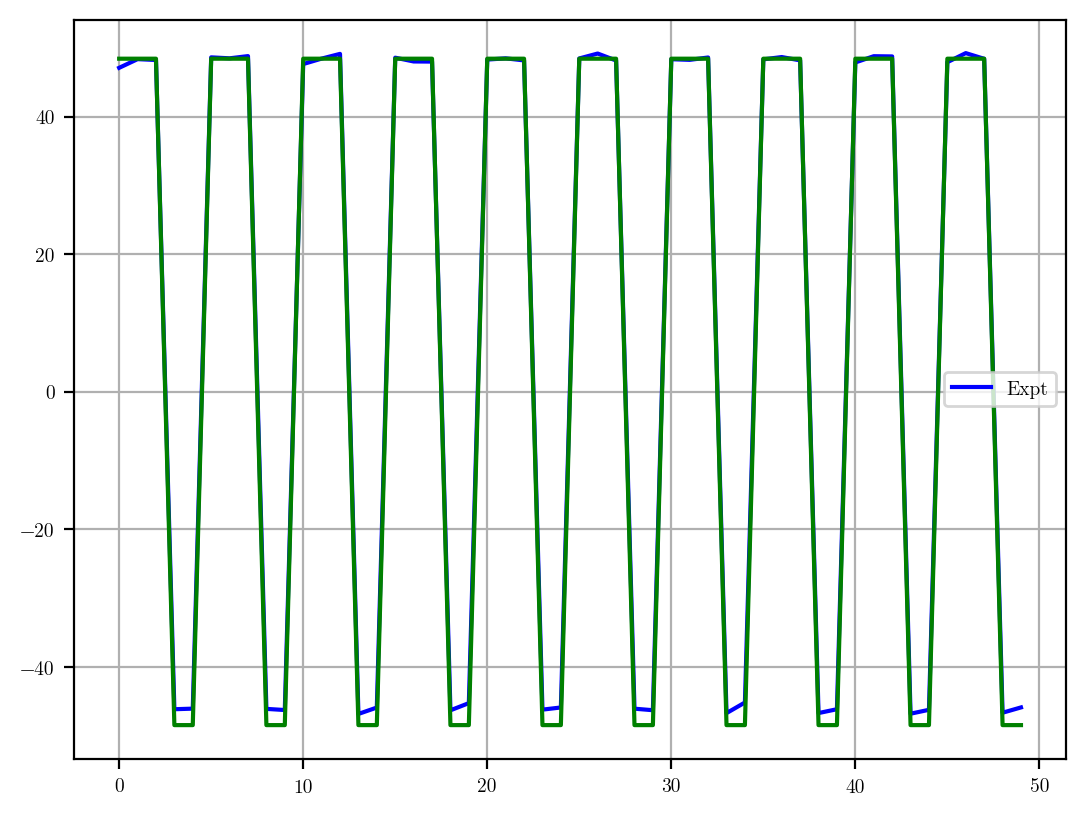

In [51]:
plt.plot(td.mean(0), label='Expt')
# plt.axhline(5*DMD.PIXEL_SIZE/2)
# plt.axhline(-5*DMD.PIXEL_SIZE/2)
plt.plot(np.arange(0, 50), 5*DMD.PIXEL_SIZE/2 * np.sign(np.sin(np.arange(0, 50) * 0.4 * np.pi + 0.00000000000001)))
plt.legend()

In [21]:
def sssum(N):
    return (np.arange(N) ** 2) .sum()

In [23]:
sssum(51) / sssum(50)

1.061842918985776

In [30]:
sssum(51)

42925

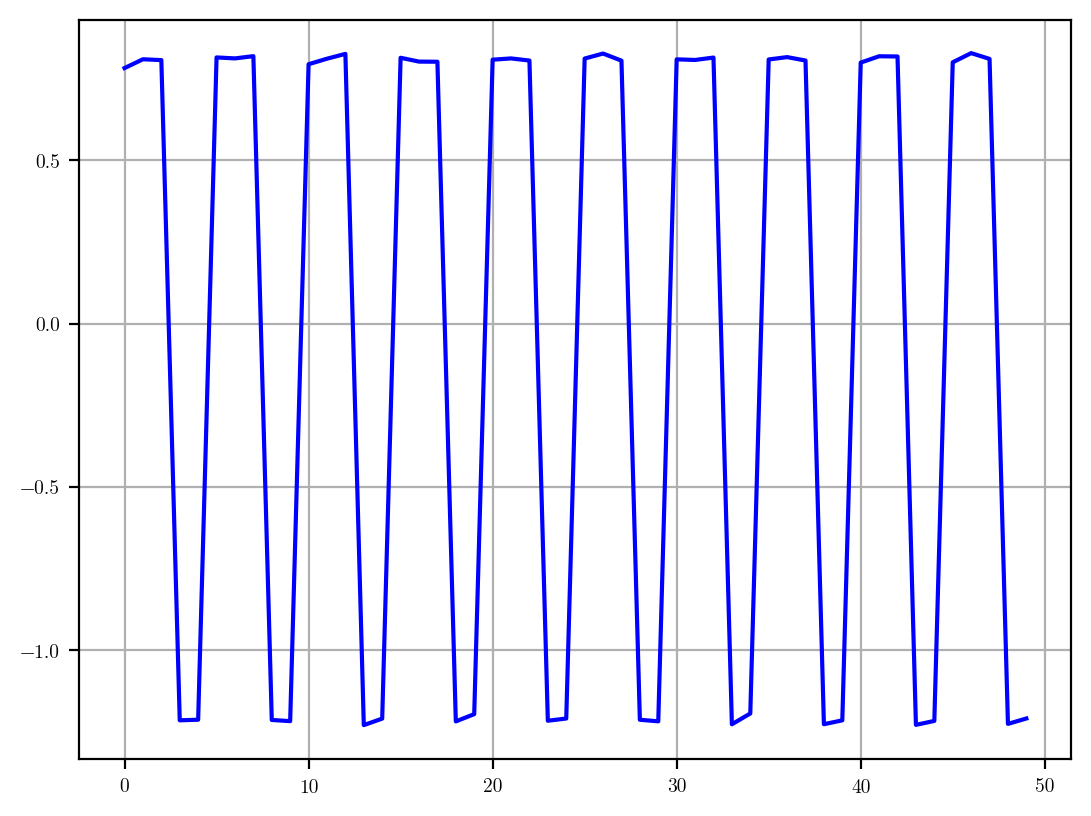

In [63]:
plt.plot(td.mean(0))

In [73]:
def I(f):
    return np.abs((td.mean(0) * np.exp(-2j*np.pi * f * np.arange(50))).sum())**2 / 50

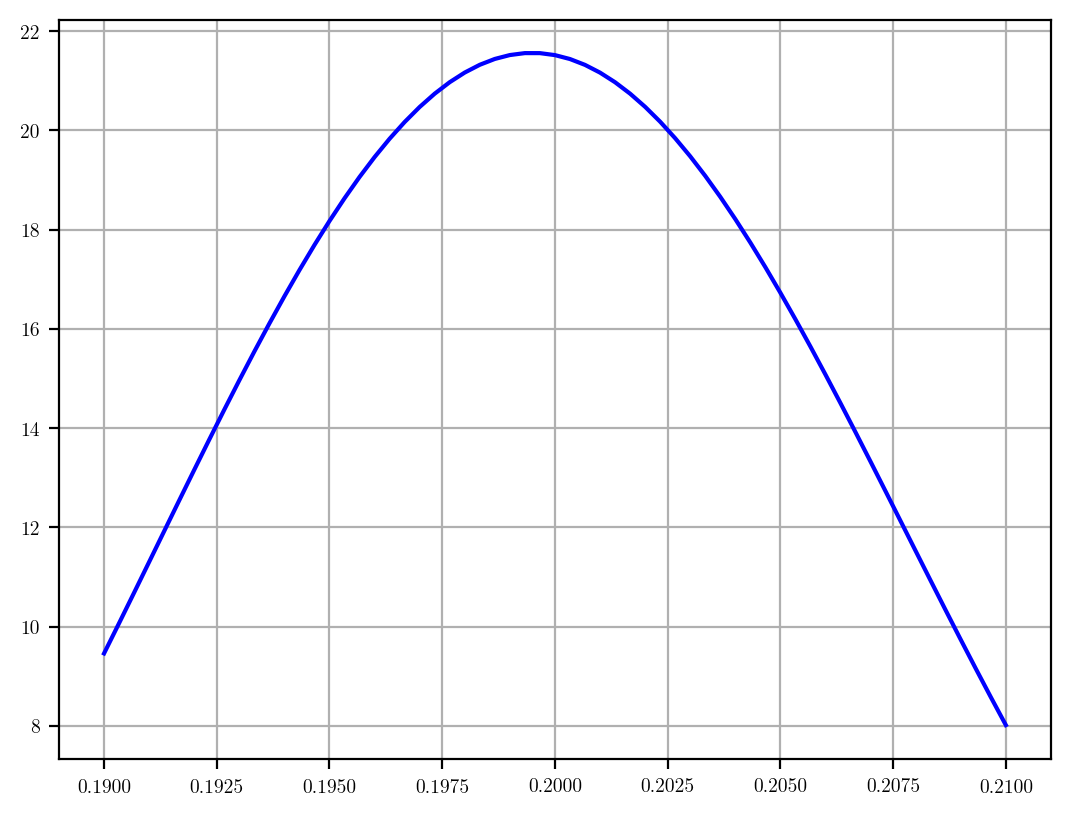

In [75]:
plt.plot(np.linspace(0.19, 0.21, 61), [I(f_) for f_ in np.linspace(0.19, 0.21, 61)])